<span style="font-size:2em; font-weight:bold;"> Variogram, Correlation and Kriging Estimation (VarioCorreKrigE): Cross-variogram and cross-correlation estimation and model fitting </span>
***

In this notebook we explore the cross‑variogram and cross‑correlation modelling capabilities of variofit and correfit using a dataset of ground‑motion residuals. The residuals are event‑normalized, meaning that for each event (evid) the associated station residuals (sta) have zero mean and unit variance. This normalization is essential:

- For variogram models, the sill should be approximately 1, so we typically fix the partial sill to 1 and estimate only the range and nugget.
- For correlation models, the sill is implicitly 0 (correlation → 1 at zero distance), so only the correlation‑decay parameters are estimated.

Cross‑variograms and cross‑correlations quantify between‑component spatial dependence, such as the spatial relationship between two IMs (e.g., pSA at different periods), or between horizontal components.

We present examples in two categories:

- cross-variofit Examples:
1) Example 1: fitting a single cross-variogram
2) Example 2: Fitting multiple variograms based on index e.g., a cross-variogram per pSA
3) Example 3: Semivariance to correlation for cross-semivariograms (similar to variofit)

- cross-correfit Examples:
1) Example 1: fitting a single cross-correlation model
2) Example 2: Fitting multiple cross-correlation models based on index e.g., pSA

# 1.0 Import Modules and Data

## 1.1 Import Modules

### 1.1.1 General Use

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

### 1.1.2 variocorrekrige

In [2]:
from VarioCorreKrigE.variofit import crossvariofit, multicrossvariofit
from VarioCorreKrigE.correfit import correfit, crosscorrefit, multicrosscorrefit
from VarioCorreKrigE.variofit import VARIOGRAM_MODELS
from VarioCorreKrigE.correfit import CORRELATION_MODELS
print('list of variogram model: ', VARIOGRAM_MODELS)
print('list of correlation models: ', CORRELATION_MODELS)

list of variogram model:  {'spherical': <function spherical at 0x0000027A47975580>, 'exponential': <function exponential at 0x0000027A47975800>, 'gaussian': <function gaussian at 0x0000027A47975940>, 'cubic': <function cubic at 0x0000027A479759E0>, 'powered_exponential': <function powered_exponential at 0x0000027A47975A80>, 'matern': <function matern at 0x0000027A47975B20>, 'damped_cosine_angle': <function damped_cosine_angle at 0x0000027A47975BC0>, 'angular_dissimilarity': <function angular_dissimilarity at 0x0000027A47975C60>}
list of correlation models:  {'spherical': <function spherical at 0x0000027A47977B00>, 'exponential': <function exponential at 0x0000027A47977BA0>, 'gaussian': <function gaussian at 0x0000027A47977C40>, 'cubic': <function cubic at 0x0000027A47977CE0>, 'powered_exponential': <function powered_exponential at 0x0000027A47977D80>, 'matern': <function matern at 0x0000027A47977E20>, 'damped_cosine_angle': <function damped_cosine_angle at 0x0000027A47977EC0>, 'angular

## 1.2 Import Data

In [3]:
im_dwbar = pd.read_csv(r'Data/im_dwbar.csv')

# 2.0 cross-variofit examples

## 2.1 Example 1: Single Fit

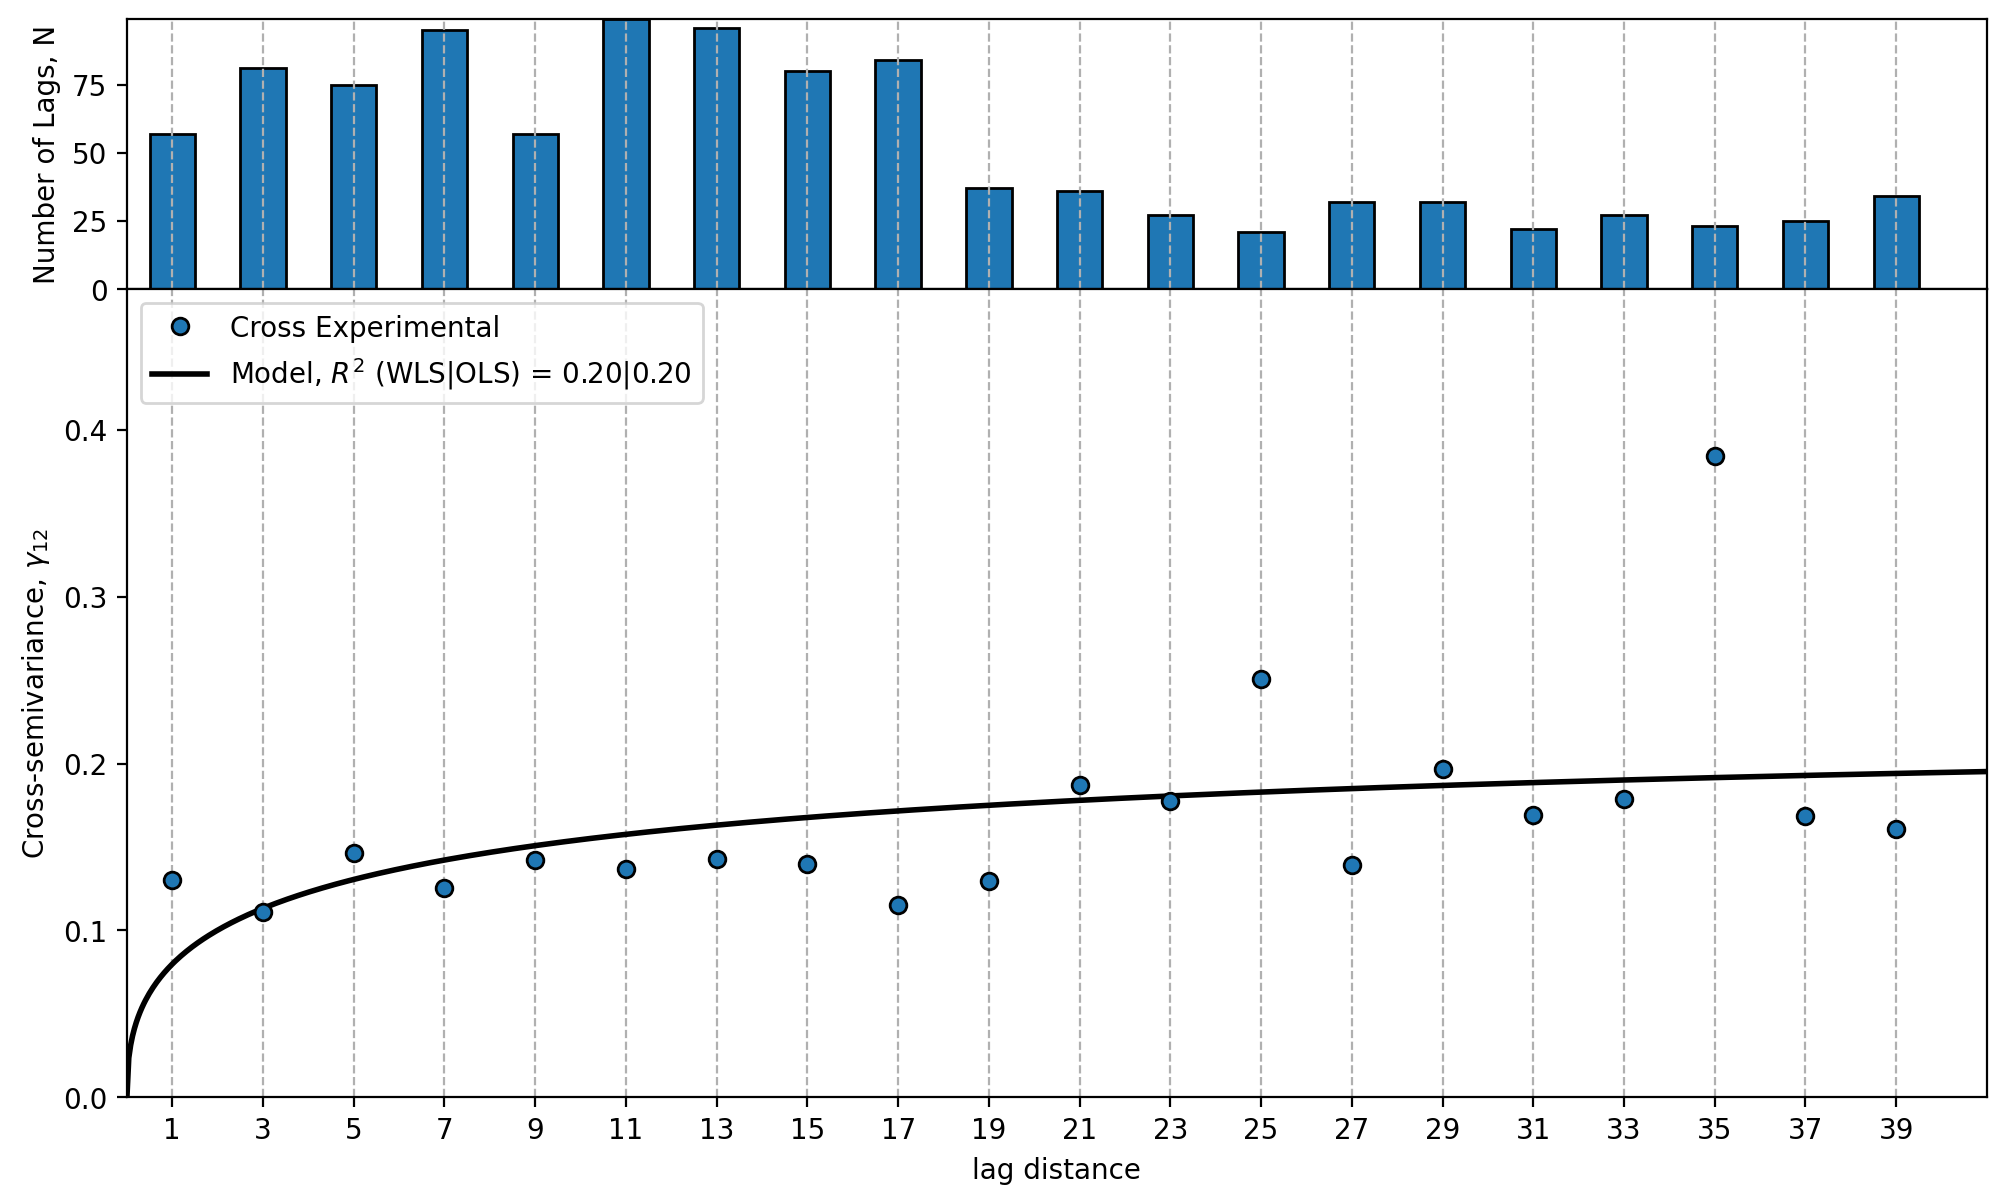

In [4]:
estimator = "Matheron"
model = "powered_exponential"
weight_fn = None
weight_params = None

im_dwbar_test = im_dwbar[im_dwbar.evid=='2016p858000'].reset_index(drop = True)

h_lag, n_obs, gamma12, params, r2_wls, r2_ols = crossvariofit(
        values1=im_dwbar_test['PGA'],
        values2=im_dwbar_test['PGA'],
        coordinates=im_dwbar_test[['lat','lon']],
        distance_type="geographic",
        max_distance=40,
        bin_size=2,
        estimator_type="Matheron",
        model_type=model,
        weight_fn=weight_fn,
        weight_params=weight_params,
        fix_nugget=True,
        fix_sill=False,
        allow_negative_sill=False,
        plot=True
)

## 2.2 Example 2: Multi-fit

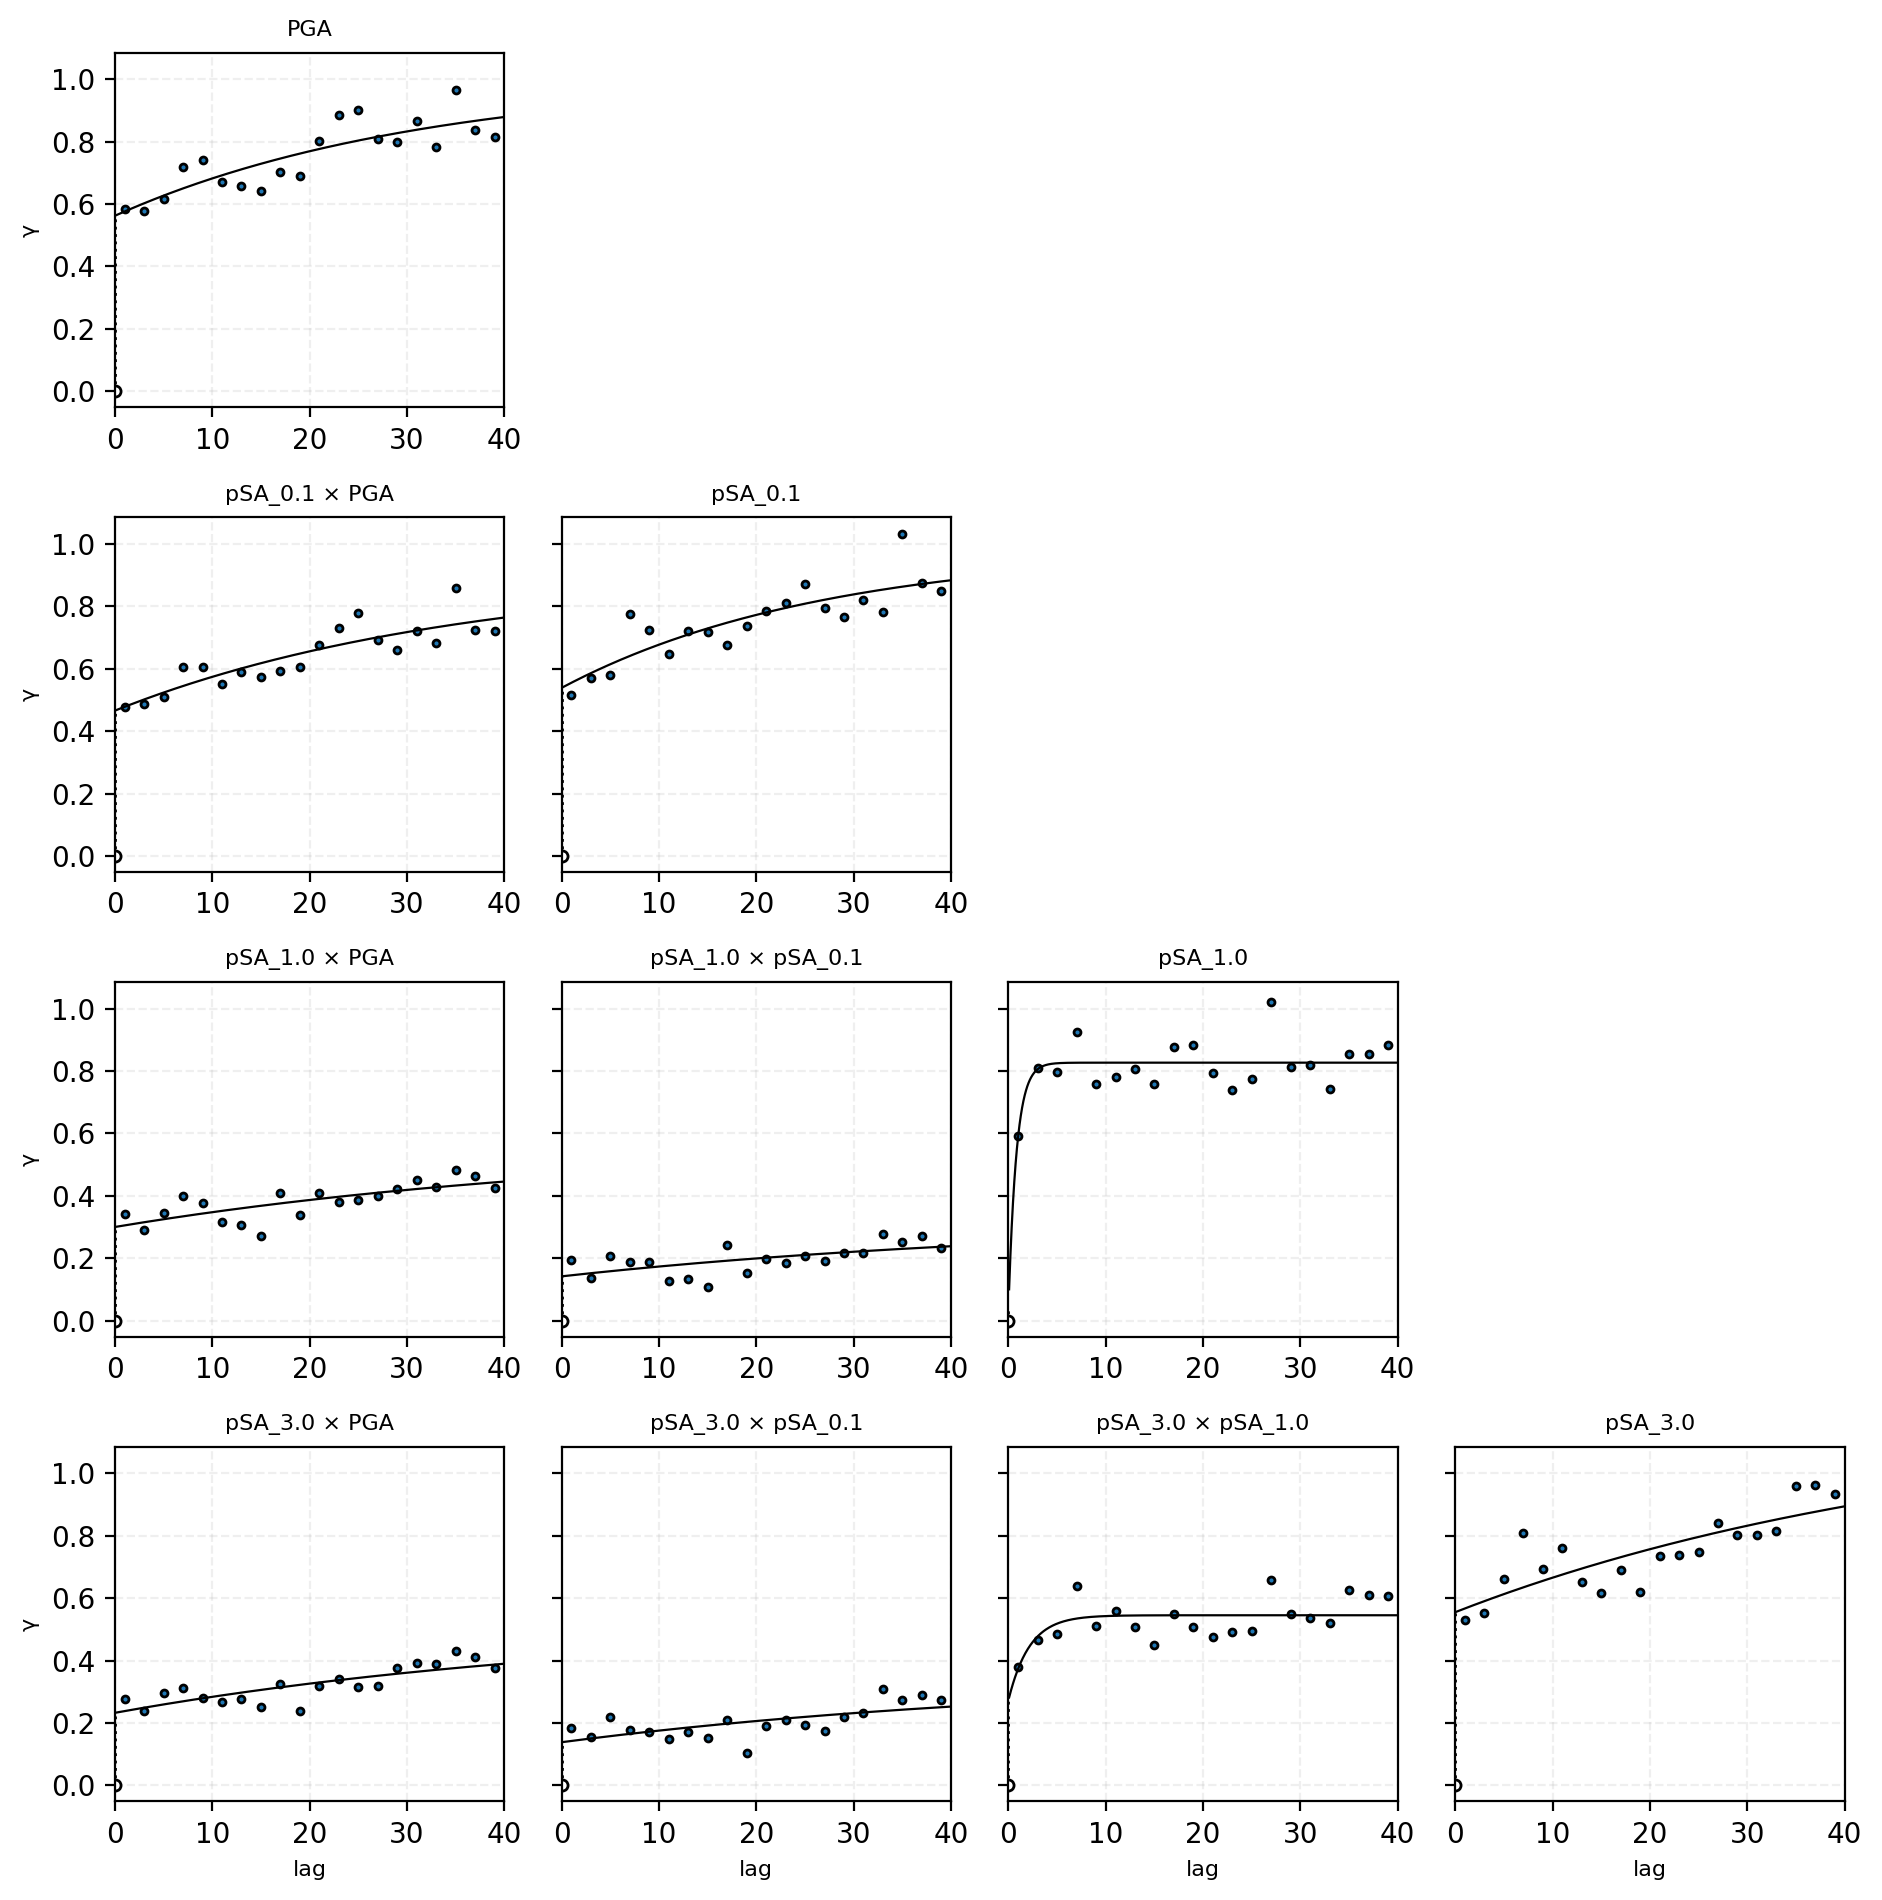

     var_i    var_j   type  n_samples  n_bins    r2_wls    r2_ols           r  \
0      PGA      PGA   auto       4115      20  0.701152  0.701152   94.734152   
1  pSA_0.1  pSA_0.1   auto       4115      20  0.711151  0.711151   80.640198   
2  pSA_1.0  pSA_1.0   auto       4115      20  0.372297  0.372297    2.481169   
3  pSA_3.0  pSA_3.0   auto       4115      20  0.649561  0.649561  156.000000   
4      PGA  pSA_0.1  cross       4115      20  0.765798  0.765798  106.758258   

         c0         b  
0  0.440897  0.562443  
1  0.445531  0.538907  
2  0.787908  0.039151  
3  0.632481  0.555147  
4  0.442109  0.465780  
dict_keys(['r', 'c0', 'b'])
              PGA   pSA_0.1   pSA_1.0   pSA_3.0
PGA      0.701152  0.765798  0.542853  0.631643
pSA_0.1  0.765798  0.711151  0.360839  0.413983
pSA_1.0  0.542853  0.360839  0.372297  0.324463
pSA_3.0  0.631643  0.413983  0.324463  0.649561
Parameters for PGA x PGA: {'r': 94.73415157356241, 'c0': 0.44089674271043156, 'b': 0.5624425188015787

In [5]:
summary, results, param_mats, r2_mats = multicrossvariofit(
    df=im_dwbar,
    values_cols=["PGA", "pSA_0.1", "pSA_1.0" ,"pSA_3.0"],
    coord_cols=("lat", "lon"),
    distance_type="geographic",
    max_distance=40.0,
    bin_size=2.0,
    estimator_type="Matheron",
    model_type="exponential",
    xmax_factor=4,
    weight_fn=None,
    weight_params=None,
    fix_nugget=False,
    fix_sill=False,
    allow_negative_sill=False,
    plot_single=False,
    plot_matrix=True,
)

print(summary.head())
print(param_mats.keys())
print(r2_mats["r2_wls"])

# After fitting cross-variograms and auto-variograms
for (vi, vj), res in results.items():
    h_lag, n_obs, gamma, params, r2_wls, r2_ols = res
    print(f"Parameters for {vi} x {vj}: {params}")

## 2.3 Example 3: cross-semivariance to cross-correlation

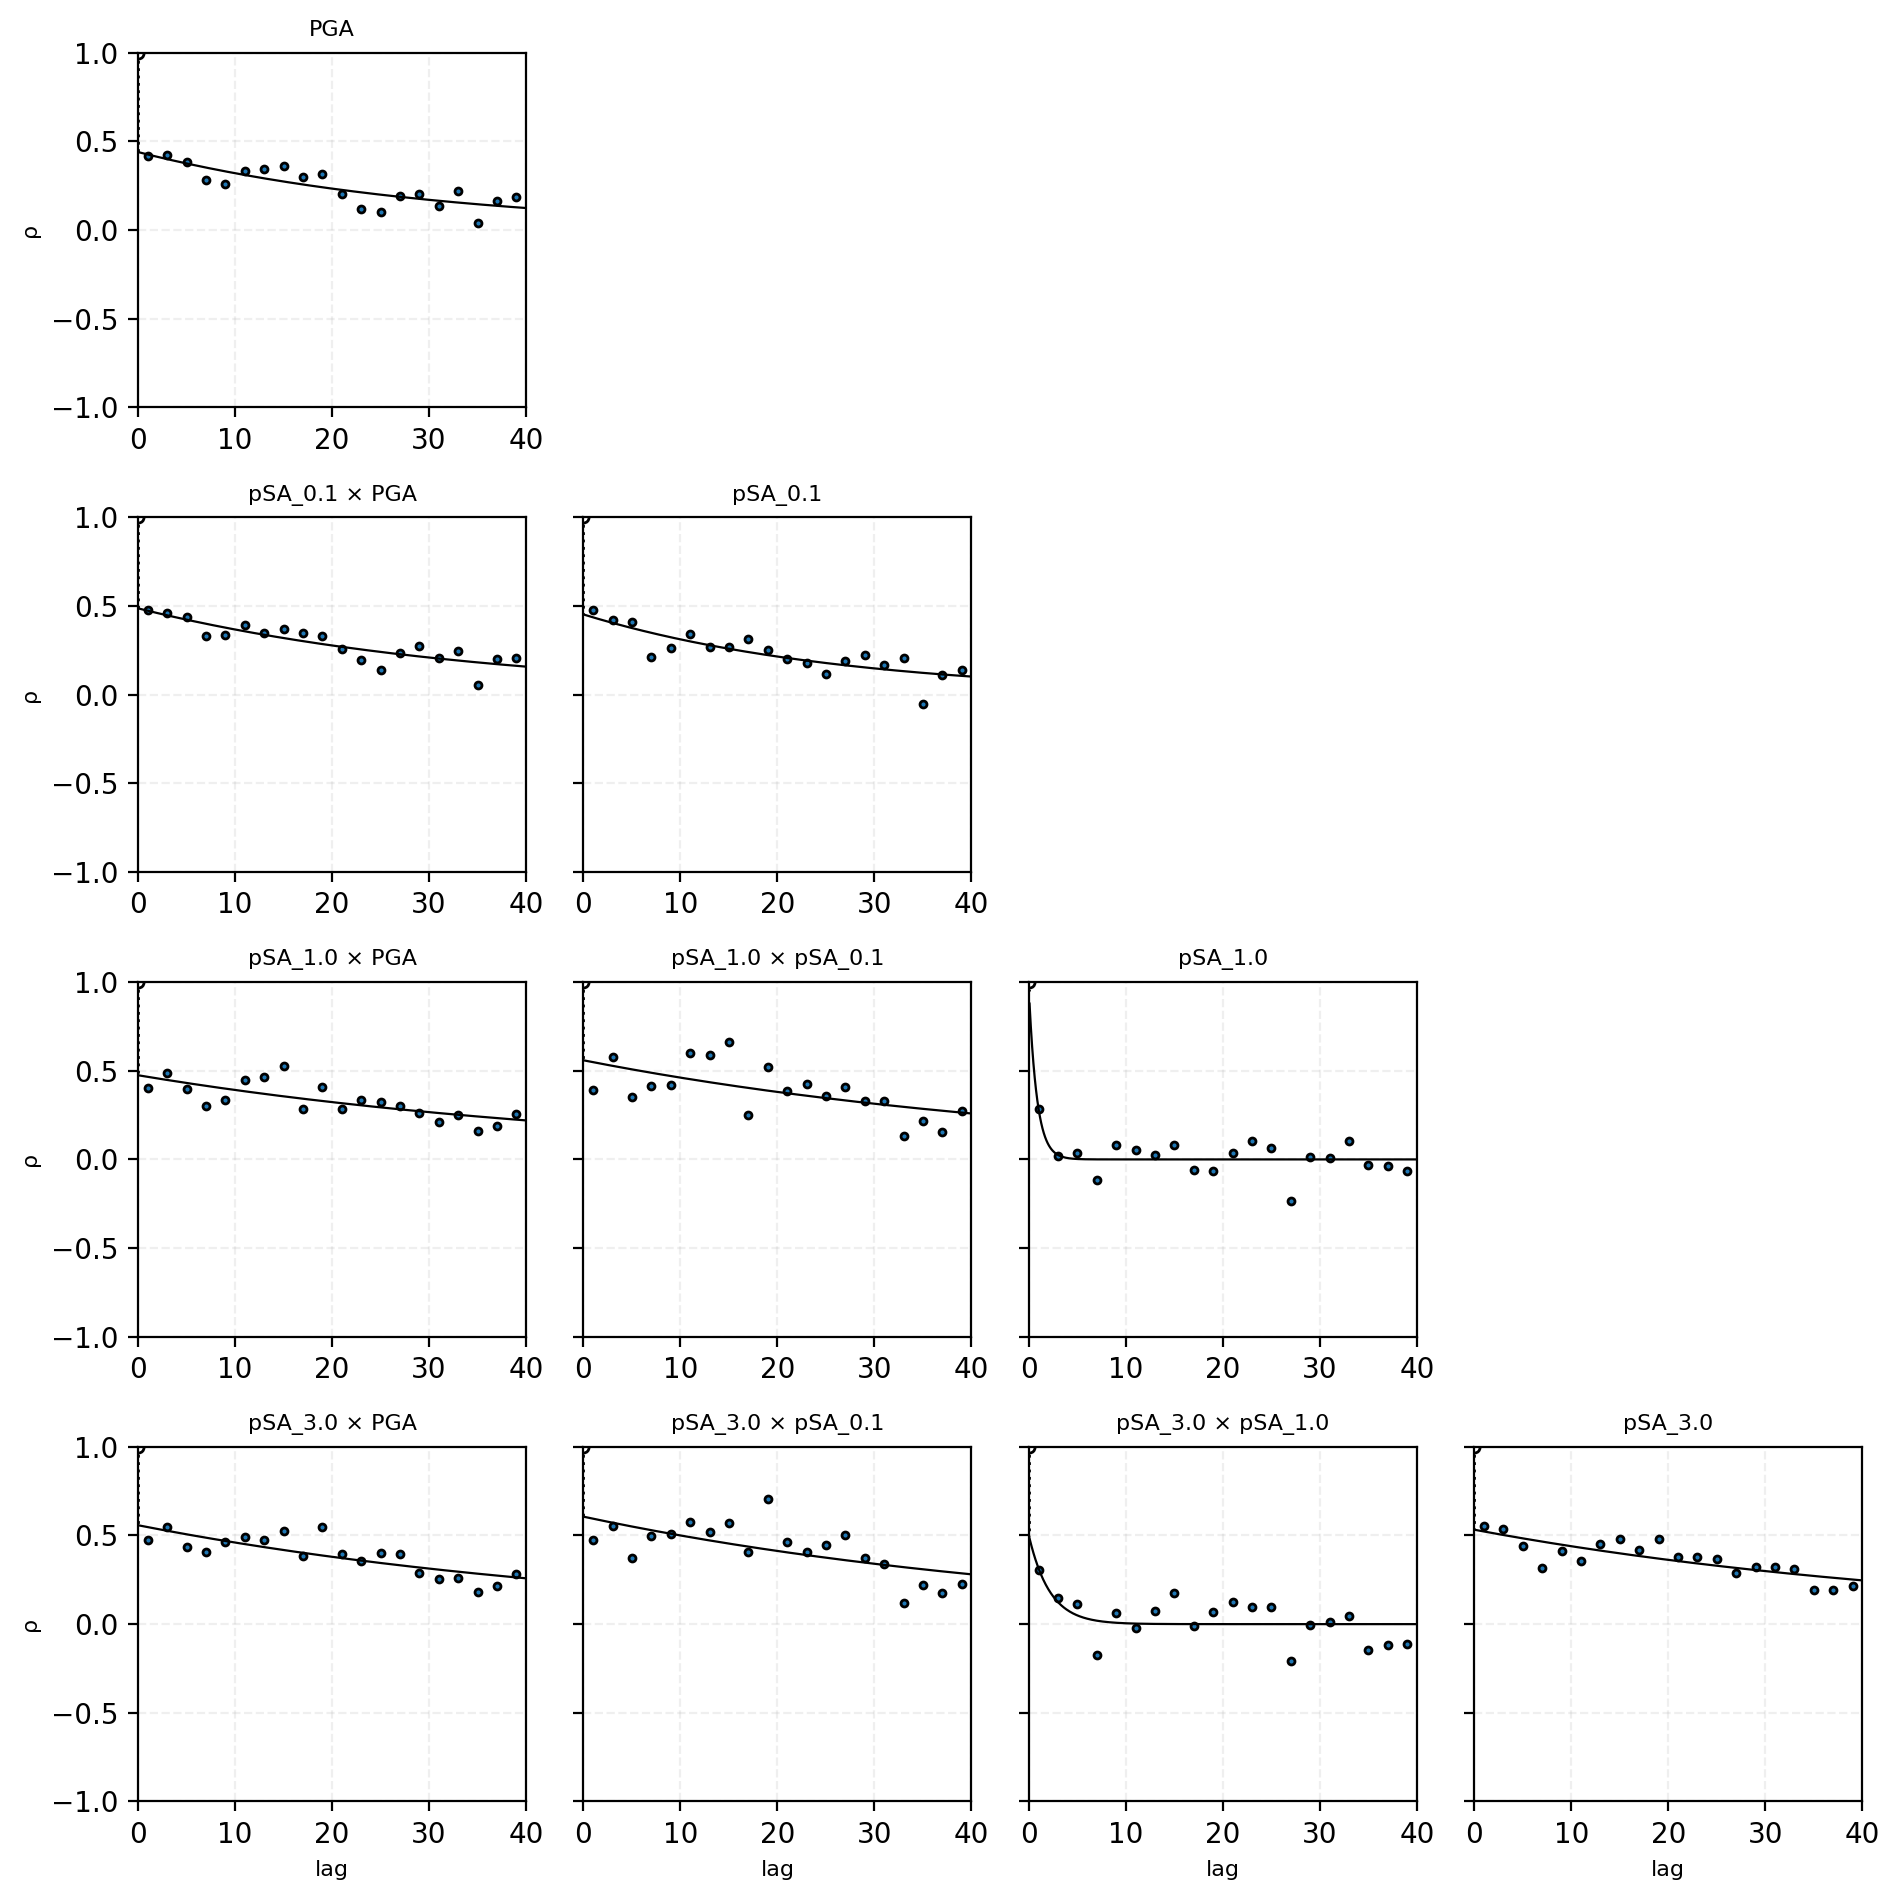

     var_i    var_j   type  n_samples  n_bins    r2_wls    r2_ols           r  \
0      PGA      PGA   auto       4115      20  0.701152  0.701152   94.734152   
1  pSA_0.1  pSA_0.1   auto       4115      20  0.711151  0.711151   80.640198   
2  pSA_1.0  pSA_1.0   auto       4115      20  0.372297  0.372297    2.481169   
3  pSA_3.0  pSA_3.0   auto       4115      20  0.649561  0.649561  156.000000   
4      PGA  pSA_0.1  cross       4115      20  0.765798  0.765798  106.758258   

         c0         b  
0  0.439429  0.560571  
1  0.452574  0.547426  
2  0.952662  0.047338  
3  0.532558  0.467442  
4  0.486964  0.513036  
dict_keys(['r', 'c0', 'b'])
              PGA   pSA_0.1   pSA_1.0   pSA_3.0
PGA      0.701152  0.765798  0.542853  0.631643
pSA_0.1  0.765798  0.711151  0.360839  0.413983
pSA_1.0  0.542853  0.360839  0.372297  0.324463
pSA_3.0  0.631643  0.413983  0.324463  0.649561
Parameters for PGA x PGA: {'r': 94.73415157356241, 'c0': 0.4394293731175334, 'b': 0.5605706268824666}

In [6]:
summary, results, param_mats, r2_mats = multicrossvariofit(
    df=im_dwbar,
    values_cols=["PGA", "pSA_0.1", "pSA_1.0" ,"pSA_3.0"],
    coord_cols=("lat", "lon"),
    distance_type="geographic",
    max_distance=40.0,
    bin_size=2.0,
    estimator_type="Matheron",
    model_type="exponential",
    xmax_factor=4,
    weight_fn=None,
    weight_params=None,
    fix_nugget=False,
    fix_sill=False,
    allow_negative_sill=False,
    plot_single=False,
    plot_matrix=True,
    transform='correlation'
)

print(summary.head())
print(param_mats.keys())
print(r2_mats["r2_wls"])

# After fitting cross-variograms and auto-variograms
for (vi, vj), res in results.items():
    h_lag, n_obs, gamma, params, r2_wls, r2_ols = res
    print(f"Parameters for {vi} x {vj}: {params}")

# 3.0 Cross-correfit examples

## 3.1 Example 1: Single fit

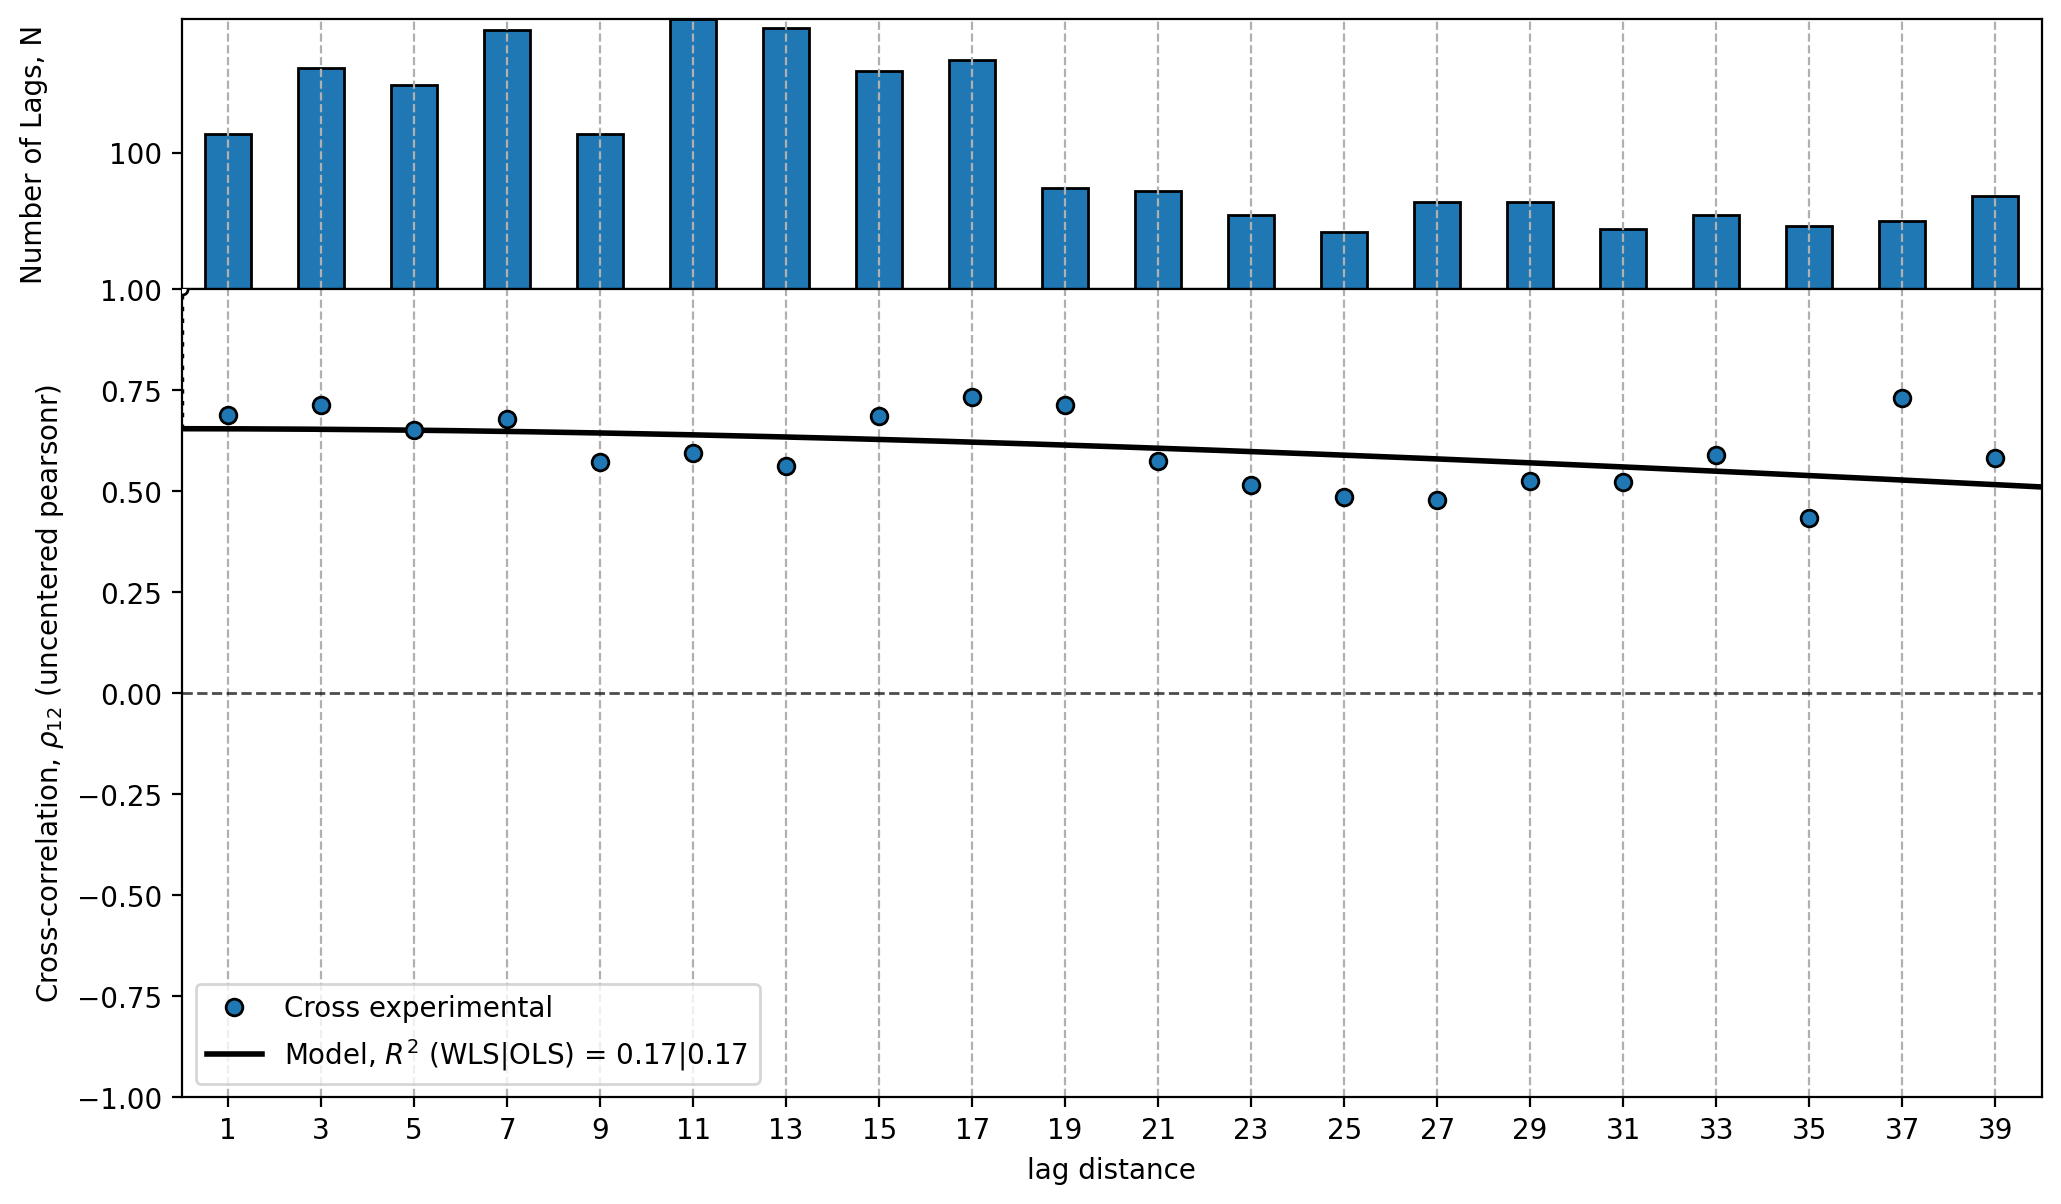

In [7]:
correlation_type = "uncentered pearsonr"   # or "uncentered pearsonr" / "spearman"
model = "powered_exponential"
weight_fn = None
weight_params = None

im_dwbar_test = im_dwbar[im_dwbar.evid == '2016p858000'].reset_index(drop=True)

h_lag, n_obs, rho12, params, r2_wls, r2_ols = crosscorrefit(
    values1=im_dwbar_test["PGA"],
    values2=im_dwbar_test["pSA_0.1"],
    coordinates=im_dwbar_test[["lat", "lon"]],
    distance_type="geographic",
    max_distance=40,
    bin_size=2,
    correlation_type=correlation_type,
    model_type=model,
    weight_fn=weight_fn,
    weight_params=weight_params,
    max_lagfit_factor=4,
    fix_alpha=False,
    plot=True,
)

## 3.2 Example 2: Multi-fit

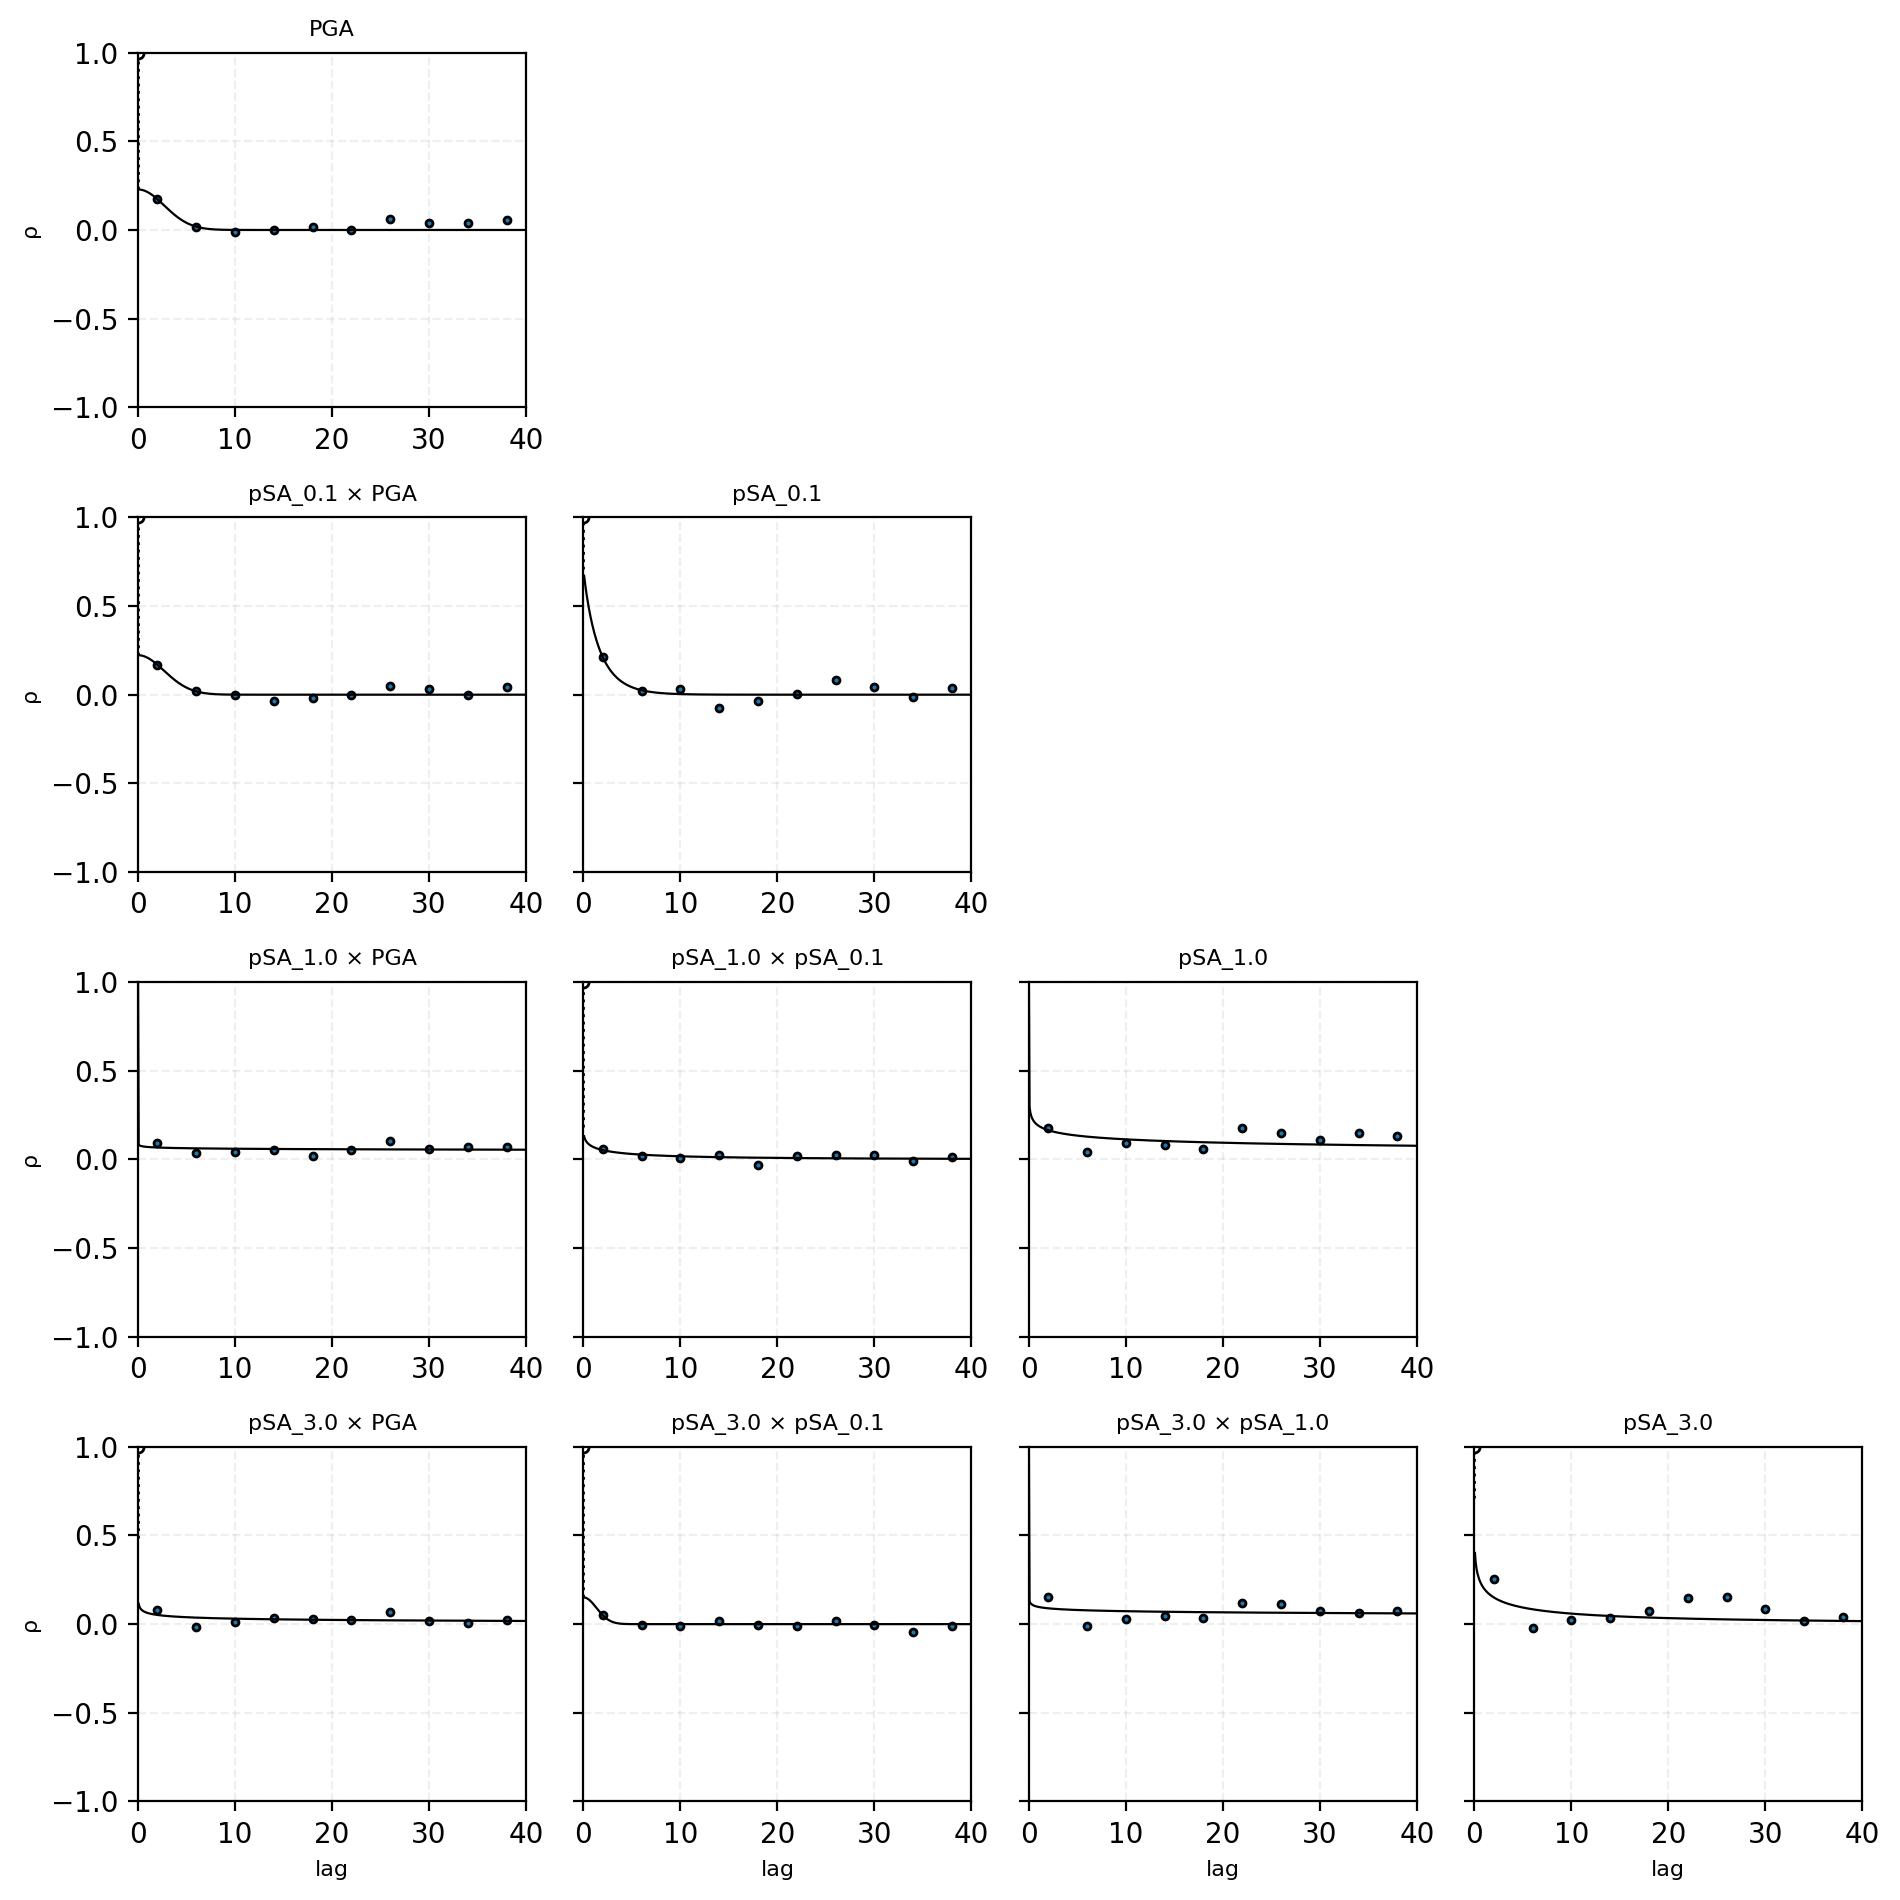

     var_i    var_j   type  n_samples  n_bins    r2_wls    r2_ols           r  \
0      PGA      PGA   auto       4115      10  0.577500  0.577500    6.570233   
1      PGA  pSA_0.1  cross       4115      10  0.767538  0.767538    6.606718   
2      PGA  pSA_1.0  cross       4115      10 -0.012853 -0.012853  152.000000   
3      PGA  pSA_3.0  cross       4115      10  0.107032  0.107032   19.044889   
4  pSA_0.1  pSA_0.1   auto       4115      10  0.667102  0.667102    5.341064   

       beta     alpha        c0         b  sigma2  
0  2.000000  0.228594  0.228594  0.771406     1.0  
1  1.985918  0.222874  0.222874  0.777126     1.0  
2  0.024137  1.000000  1.000000  0.000000     1.0  
3  0.129255  0.486770  0.486770  0.513230     1.0  
4  0.923325  0.707387  0.707387  0.292613     1.0  
dict_keys(['r', 'beta', 'alpha', 'c0', 'b', 'sigma2'])
              PGA   pSA_0.1   pSA_1.0   pSA_3.0
PGA      0.577500  0.767538 -0.012853  0.107032
pSA_0.1  0.767538  0.667102  0.344189  0.447956
pS

In [8]:
summary, results, param_mats, r2_mats = multicrosscorrefit(
    df=im_dwbar,
    values_cols=["PGA", "pSA_0.1", "pSA_1.0", "pSA_3.0"],
    coord_cols=("lat", "lon"),
    distance_type="geographic",
    max_distance=40.0,
    bin_size=4.0,
    correlation_type="pearsonr",
    model_type="powered_exponential",
    max_lagfit_factor=4,
    weight_fn=None,
    weight_params=None,
    fix_alpha=False,
    plot_single=False,
    plot_matrix=True,
)

print(summary.head())
print(param_mats.keys())
print(r2_mats["r2_wls"])

for (vi, vj), res in results.items():
    h_lag, n_obs, rho, params, r2_wls, r2_ols = res
    print(f"Parameters for {vi} x {vj}: {params}")